Step 1: Preparing Data...
Data preparation complete.

Step 2: Exploratory Data Analysis...
Generating histogram...


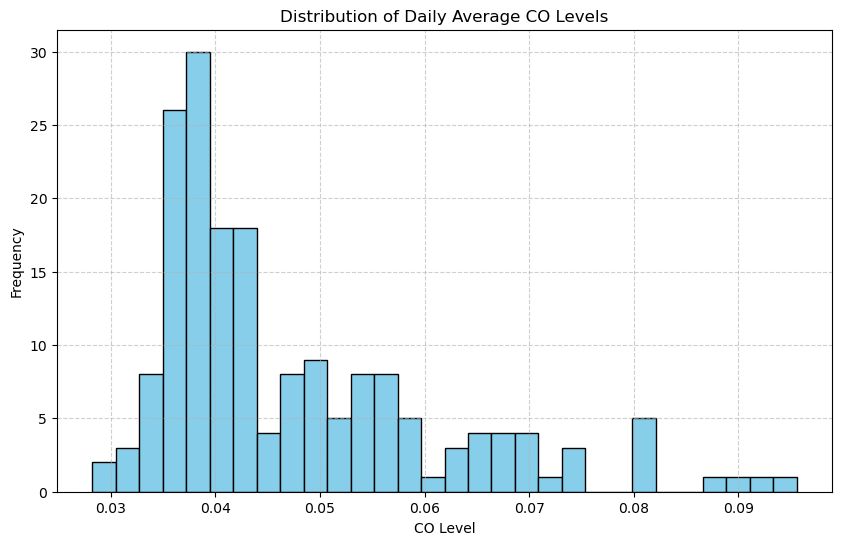

Performing Fourier Transform...


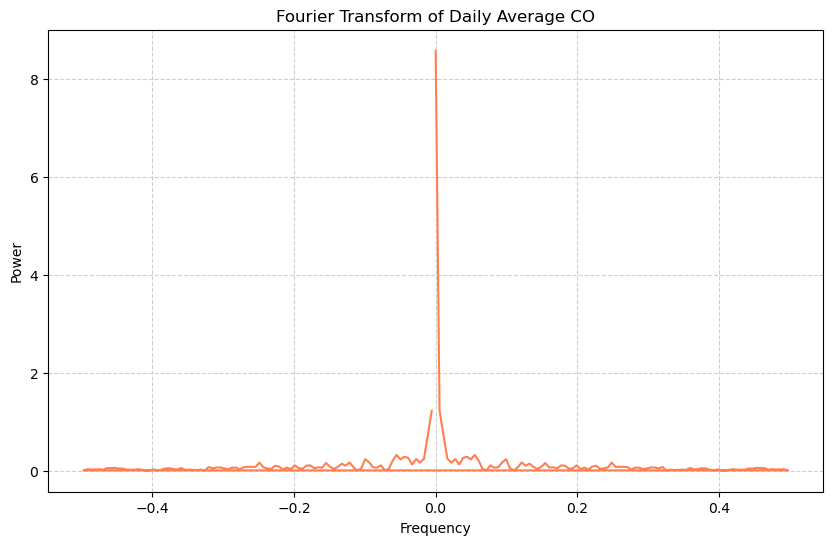

EDA complete.

Step 3: Preparing Data for the Model...
Data sequencing and splitting complete.

Step 4: Building and Training the LSTM Model...


/Users/sakdahomhuan/miniforge3/envs/udfire/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 147ms/step - loss: 0.0353 - val_loss: 0.1194 - learning_rate: 0.0010
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0235 - val_loss: 0.0368 - learning_rate: 0.0010
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0179 - val_loss: 0.0471 - learning_rate: 0.0010
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0177 - val_loss: 0.0304 - learning_rate: 0.0010
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0125 - val_loss: 0.0461 - learning_rate: 0.0010
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0136 - val_loss: 0.0333 - learning_rate: 0.0010
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0113 - val_loss: 0.0280 - learning_rate: 0.0010
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0126 - val_loss: 0.0293 - learning_rate: 0.0010
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0113 - val_loss: 0.0510 - learning_rate: 0.0010
Epoch 10/100
4/4 ━━━━━━━━━━

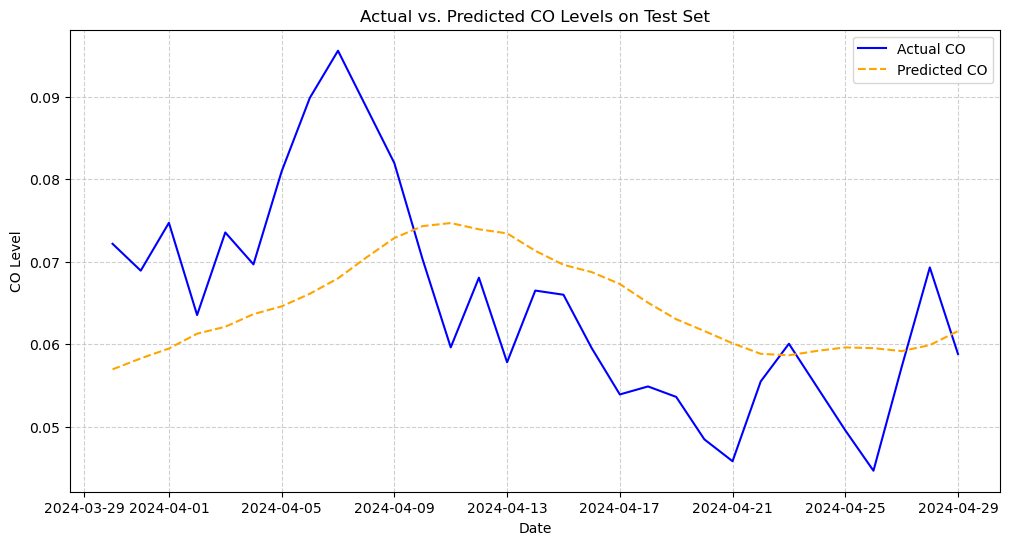

Model evaluation complete.

Step 6 & 7: Forecasting Future CO Levels and Saving Model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


Forecasting complete and model saved as 'co_lstm_model.h5'.

Step 8: Final Report...

CO Forecast for the Next 7 Days:
        Date  Forecasted_CO
0 2024-04-30       0.062031
1 2024-05-01       0.062792
2 2024-05-02       0.063423
3 2024-05-03       0.064309
4 2024-05-04       0.064833
5 2024-05-05       0.065296
6 2024-05-06       0.065246


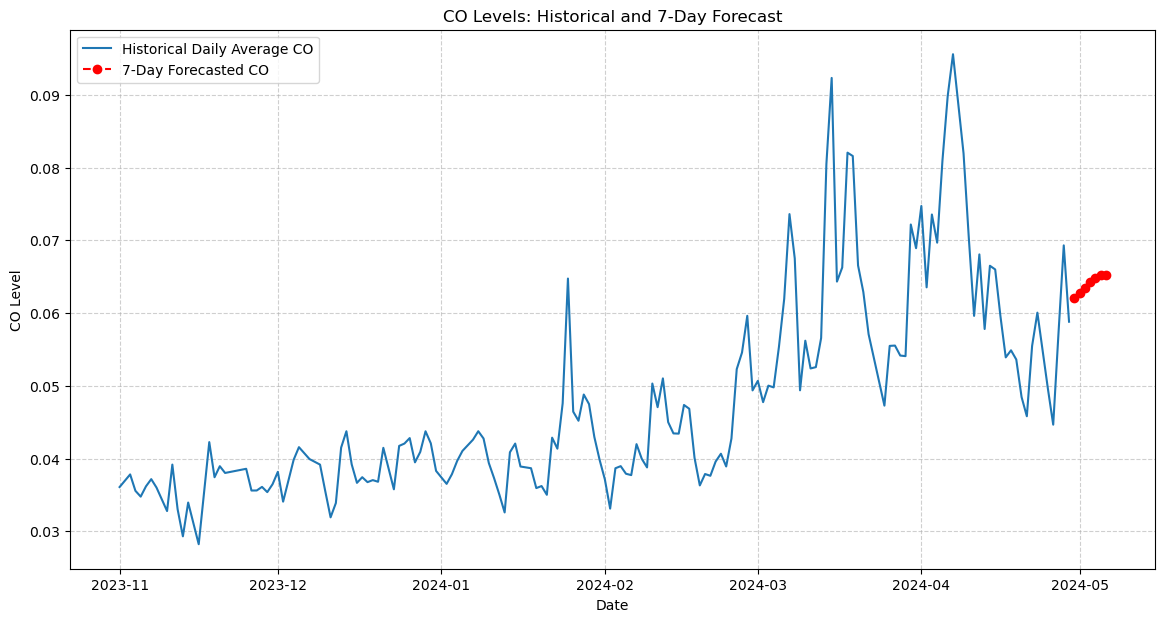

Reporting complete.


In [2]:
# 1. Install necessary libraries (run this in a separate cell first)
# !pip install tensorflow pandas scikit-learn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 2. Data Preparation
print("Step 1: Preparing Data...")
# Load and preprocess data from your uploaded file
df = pd.read_csv('CO_hex30_urban.csv')
df['date'] = pd.to_datetime(df['date'])
# Sort before setting index
df = df.sort_values(by=['id', 'date'])
# Set 'date' as the index for time-based interpolation
df = df.set_index('date')

# Handle missing values with time interpolation
df['CO'] = df.groupby('id')['CO'].transform(lambda x: x.interpolate(method='time'))
df = df.dropna()
# Reset index to make 'date' a column again
df = df.reset_index()
print("Data preparation complete.")

# 3. Exploratory Data Analysis
print("\nStep 2: Exploratory Data Analysis...")
# Calculate daily average CO
daily_avg_co = df.groupby('date')['CO'].mean().reset_index()
daily_avg_co = daily_avg_co.set_index('date')

# Plot histogram
print("Generating histogram...")
plt.figure(figsize=(10, 6))
plt.hist(daily_avg_co['CO'], bins=30, edgecolor='black', color='skyblue')
plt.title('Distribution of Daily Average CO Levels')
plt.xlabel('CO Level')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Fourier Transform
print("Performing Fourier Transform...")
data_fft = np.fft.fft(daily_avg_co['CO'].values)
power = np.abs(data_fft)
freq = np.fft.fftfreq(len(daily_avg_co))

plt.figure(figsize=(10, 6))
plt.plot(freq, power, color='coral')
plt.title('Fourier Transform of Daily Average CO')
plt.xlabel('Frequency')
plt.ylabel('Power')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
print("EDA complete.")

# 4. Data Preparation for the Model
print("\nStep 3: Preparing Data for the Model...")
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 30
co_values = daily_avg_co['CO'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_co = scaler.fit_transform(co_values)
X, y = create_sequences(scaled_co, seq_length)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print("Data sequencing and splitting complete.")

# 5. Model Building and Training
print("\nStep 4: Building and Training the LSTM Model...")
model = Sequential([
    Bidirectional(LSTM(100, return_sequences=True, input_shape=(X_train.shape[1], 1))),
    Dropout(0.2),
    Bidirectional(LSTM(100)),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1,
                    callbacks=[early_stopping, reduce_lr], verbose=1)
print("Model training complete.")

# 6. Model Evaluation
print("\nStep 5: Evaluating the Model...")
y_pred = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"\nModel Evaluation Metrics:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R-squared: {r2:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(daily_avg_co.index[-len(y_test_inv):], y_test_inv, label='Actual CO', color='blue')
plt.plot(daily_avg_co.index[-len(y_pred_inv):], y_pred_inv, label='Predicted CO', color='orange', linestyle='--')
plt.title('Actual vs. Predicted CO Levels on Test Set')
plt.xlabel('Date')
plt.ylabel('CO Level')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
print("Model evaluation complete.")

# 7. Forecasting and Saving
print("\nStep 6 & 7: Forecasting Future CO Levels and Saving Model...")
last_sequence = scaled_co[-seq_length:]
forecast = []
current_batch = last_sequence.reshape((1, seq_length, 1))
for i in range(7):
    current_pred = model.predict(current_batch)[0]
    forecast.append(current_pred)
    current_batch = np.append(current_batch[:, 1:, :], [[current_pred]], axis=1)

forecast_inv = scaler.inverse_transform(forecast)
last_date = daily_avg_co.index[-1]
future_dates = pd.to_datetime([last_date + pd.DateOffset(days=i) for i in range(1, 8)])
model.save('co_lstm_model.h5')
print("Forecasting complete and model saved as 'co_lstm_model.h5'.")

# 8. Reporting
print("\nStep 8: Final Report...")
print("\nCO Forecast for the Next 7 Days:")
forecast_df = pd.DataFrame({'Date': future_dates, 'Forecasted_CO': forecast_inv.flatten()})
print(forecast_df)

plt.figure(figsize=(14, 7))
plt.plot(daily_avg_co.index, daily_avg_co['CO'], label='Historical Daily Average CO')
plt.plot(future_dates, forecast_inv, label='7-Day Forecasted CO', color='red', marker='o', linestyle='--')
plt.title('CO Levels: Historical and 7-Day Forecast')
plt.xlabel('Date')
plt.ylabel('CO Level')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
print("Reporting complete.")